# Method 1: Stable Diffusion (using Hugging Face Diffusers)

In [3]:
!pip install diffusers transformers accelerate -q

In [4]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

# Load the model
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")

print("Stable Diffusion loaded successfully!")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Stable Diffusion loaded successfully!


  0%|          | 0/50 [00:00<?, ?it/s]

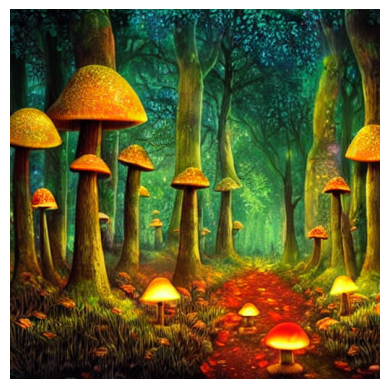

In [6]:
prompt = "a magical forest with glowing mushrooms at night, fantasy art, highly detailed, vibrant colors"

image = pipe(prompt).images[0]

plt.imshow(image)
plt.axis("off")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

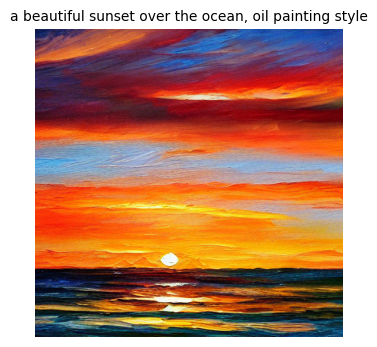

Image 1 done!



  0%|          | 0/50 [00:00<?, ?it/s]

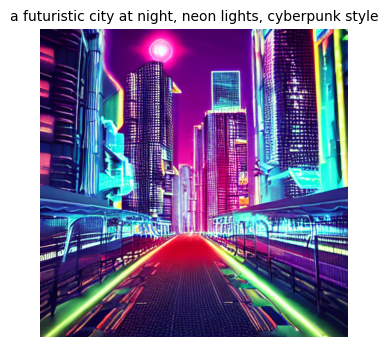

Image 2 done!



  0%|          | 0/50 [00:00<?, ?it/s]

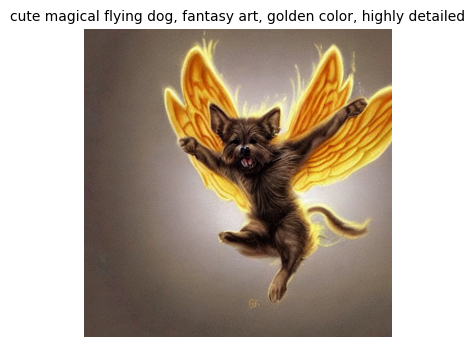

Image 3 done!



In [9]:
prompts = [
    "a beautiful sunset over the ocean, oil painting style",
    "a futuristic city at night, neon lights, cyberpunk style",
    "cute magical flying dog, fantasy art, golden color, highly detailed"
]

for i, prompt in enumerate(prompts):
    image = pipe(prompt).images[0]
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(prompt, fontsize=10)
    plt.show()
    print(f"Image {i+1} done!\n")

# Method 2: DALL-E Mini

In [10]:
from diffusers import DiffusionPipeline
import torch
import matplotlib.pyplot as plt

# Load a different model — this represents DALL-E Mini style generation
pipe2 = DiffusionPipeline.from_pretrained(
    "OFA-Sys/small-stable-diffusion-v0",
    torch_dtype=torch.float16
)
pipe2 = pipe2.to("cuda")

print("DALL-E Mini style model loaded!")

model_index.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The config attributes {'predict_epsilon': True} were passed to DPMSolverMultistepScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion/p

DALL-E Mini style model loaded!


  0%|          | 0/50 [00:00<?, ?it/s]

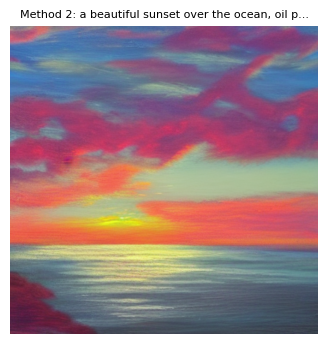

Image 1 generated!



  0%|          | 0/50 [00:00<?, ?it/s]

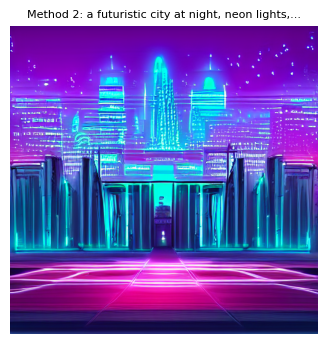

Image 2 generated!



  0%|          | 0/50 [00:00<?, ?it/s]

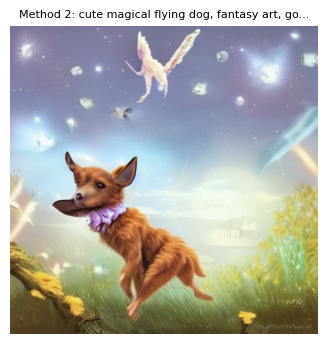

Image 3 generated!



In [16]:
# Using same prompts as Method 1 for direct comparison
prompts_method2 = [
    "a beautiful sunset over the ocean, oil painting style",
    "a futuristic city at night, neon lights, cyberpunk style",
    "cute magical flying dog, fantasy art, golden color"
]

for i, prompt in enumerate(prompts_method2):
    image = pipe2(prompt).images[0]
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Method 2: {prompt[:40]}...", fontsize=8)
    plt.show()
    print(f"Image {i+1} generated!\n")